<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  36.4MB/s    in 4.3s    

2026-05-20 19:55:57 (35.8 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


### Step 2: Import necessary libraries and load the dataset


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



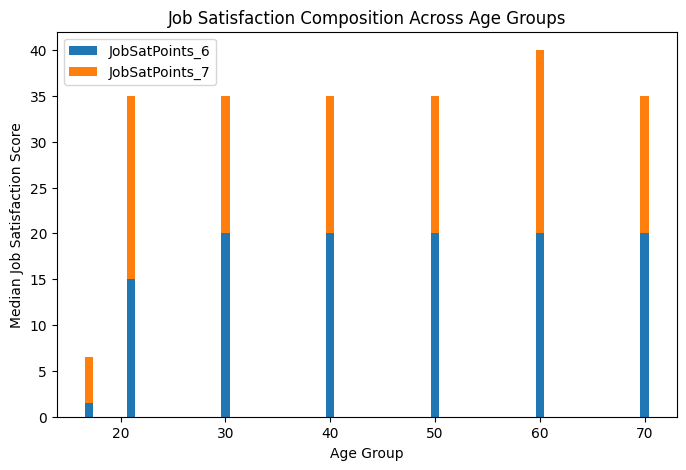

In [8]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CLEAN DATA
# -----------------------------
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df['JobSatPoints_7'] = pd.to_numeric(df['JobSatPoints_7'], errors='coerce')

# Map Age to numeric groups
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df['AgeGroup'] = df['Age'].map(age_map)

# -----------------------------
# GROUP AND AGGREGATE
# -----------------------------
age_stats = df.groupby('AgeGroup')[['JobSatPoints_6', 'JobSatPoints_7']].median()

# Remove missing groups
age_stats = age_stats.dropna()

# -----------------------------
# STACKED BAR CHART
# -----------------------------
plt.figure(figsize=(8,5))

plt.bar(
    age_stats.index,
    age_stats['JobSatPoints_6'],
    label='JobSatPoints_6'
)

plt.bar(
    age_stats.index,
    age_stats['JobSatPoints_7'],
    bottom=age_stats['JobSatPoints_6'],
    label='JobSatPoints_7'
)

plt.title("Job Satisfaction Composition Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Median Job Satisfaction Score")
plt.legend()

plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


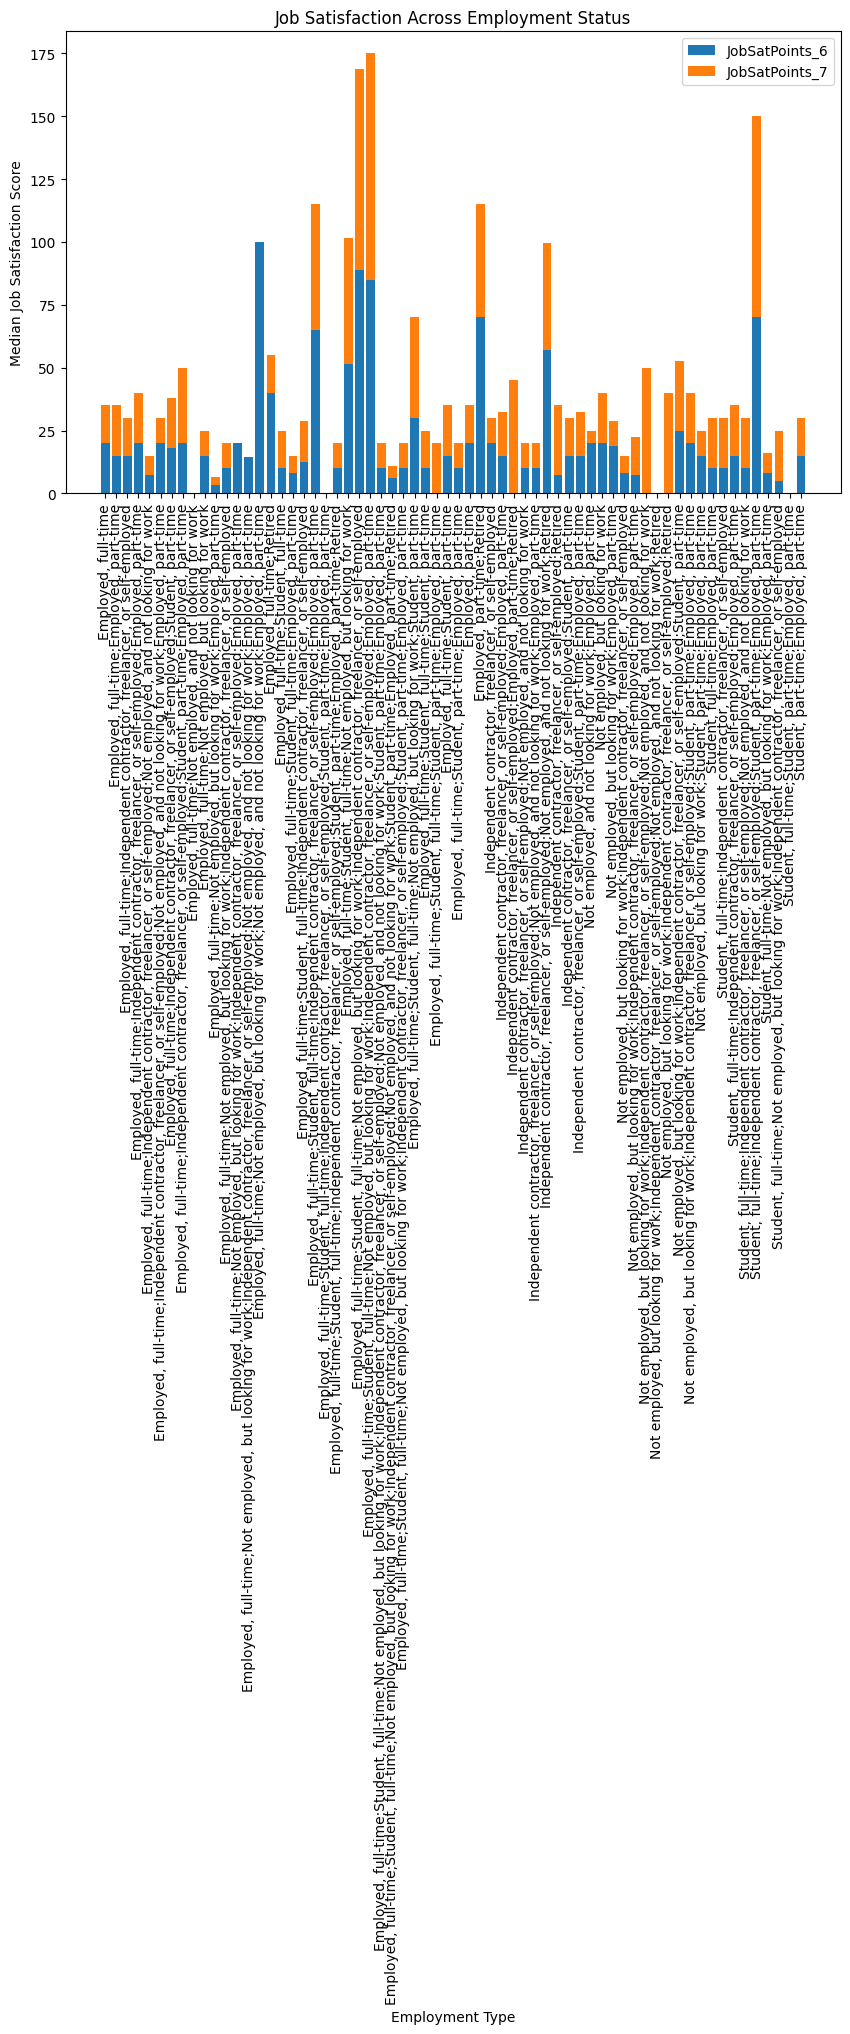

In [9]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CLEAN DATA
# -----------------------------
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df['JobSatPoints_7'] = pd.to_numeric(df['JobSatPoints_7'], errors='coerce')

# Drop missing employment values
df_emp = df[['Employment', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()

# -----------------------------
# GROUP BY EMPLOYMENT STATUS
# -----------------------------
emp_stats = df_emp.groupby('Employment')[['JobSatPoints_6', 'JobSatPoints_7']].median()

# -----------------------------
# STACKED BAR CHART
# -----------------------------
plt.figure(figsize=(10,6))

plt.bar(
    emp_stats.index,
    emp_stats['JobSatPoints_6'],
    label='JobSatPoints_6'
)

plt.bar(
    emp_stats.index,
    emp_stats['JobSatPoints_7'],
    bottom=emp_stats['JobSatPoints_6'],
    label='JobSatPoints_7'
)

plt.title("Job Satisfaction Across Employment Status")
plt.xlabel("Employment Type")
plt.ylabel("Median Job Satisfaction Score")

plt.xticks(rotation=90)
plt.legend()

plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


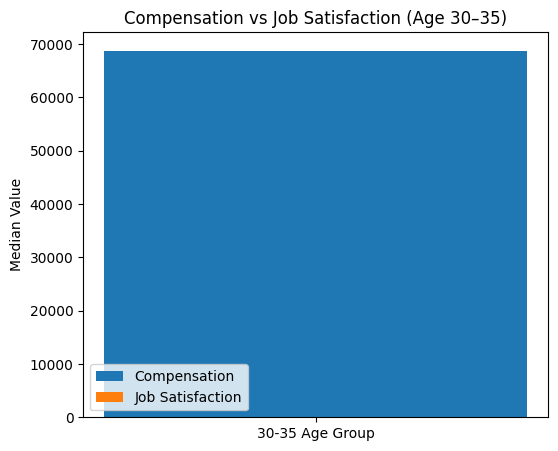

In [10]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CLEAN DATA
# -----------------------------
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Map Age to numeric groups
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df['AgeGroup'] = df['Age'].map(age_map)

# -----------------------------
# FILTER AGE 30–35 GROUP (25-34 & 35-44 approx)
# -----------------------------
df_30_35 = df[df['AgeGroup'].isin([30, 40])]

# -----------------------------
# GROUP DATA
# -----------------------------
stats = df_30_35[['ConvertedCompYearly', 'JobSatPoints_6']].median()

# Convert to DataFrame for plotting
stats = pd.DataFrame(stats).T

# -----------------------------
# STACKED BAR CHART
# -----------------------------
plt.figure(figsize=(6,5))

plt.bar(
    ['30-35 Age Group'],
    stats['ConvertedCompYearly'],
    label='Compensation'
)

plt.bar(
    ['30-35 Age Group'],
    stats['JobSatPoints_6'],
    bottom=stats['ConvertedCompYearly'],
    label='Job Satisfaction'
)

plt.title("Compensation vs Job Satisfaction (Age 30–35)")
plt.ylabel("Median Value")
plt.legend()

plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


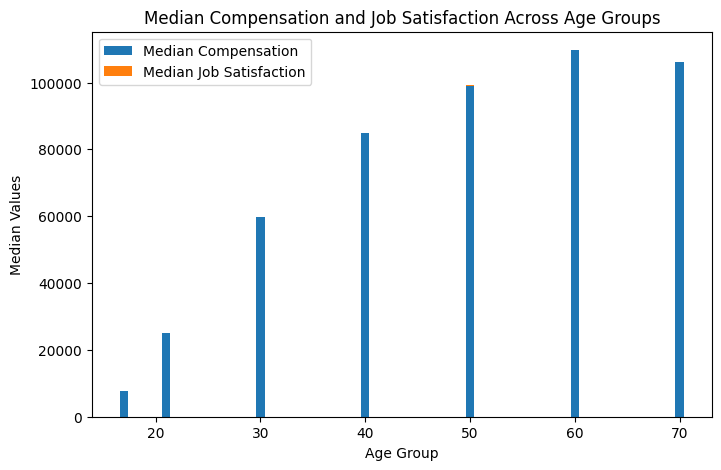

In [11]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CLEAN NUMERIC COLUMNS
# -----------------------------
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# -----------------------------
# MAP AGE TO GROUPS
# -----------------------------
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df['AgeGroup'] = df['Age'].map(age_map)

# -----------------------------
# GROUP AND COMPUTE MEDIAN
# -----------------------------
age_stats = df.groupby('AgeGroup')[['ConvertedCompYearly', 'JobSatPoints_6']].median()
age_stats = age_stats.dropna()

# -----------------------------
# STACKED BAR CHART
# -----------------------------
plt.figure(figsize=(8,5))

plt.bar(
    age_stats.index,
    age_stats['ConvertedCompYearly'],
    label='Median Compensation'
)

plt.bar(
    age_stats.index,
    age_stats['JobSatPoints_6'],
    bottom=age_stats['ConvertedCompYearly'],
    label='Median Job Satisfaction'
)

plt.title("Median Compensation and Job Satisfaction Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Median Values")
plt.legend()

plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


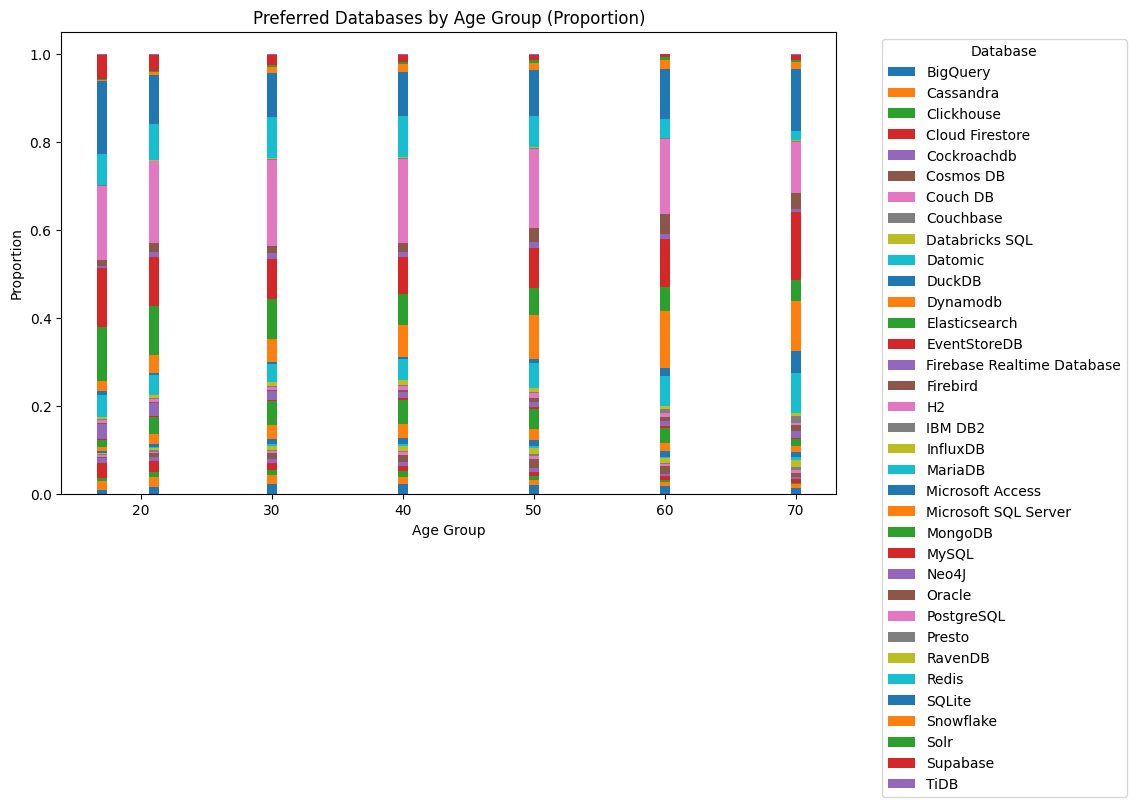

In [12]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CLEAN NUMERIC AGE GROUP
# -----------------------------
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df['AgeGroup'] = df['Age'].map(age_map)

# -----------------------------
# PREP DATABASE COLUMN
# -----------------------------
df_db = df[['AgeGroup', 'DatabaseWantToWorkWith']].dropna()

# Split multiple databases
df_db = df_db.assign(
    Database=df_db['DatabaseWantToWorkWith'].str.split(';')
).explode('Database')

df_db['Database'] = df_db['Database'].str.strip()

# -----------------------------
# GROUP AND COUNT
# -----------------------------
db_counts = df_db.groupby(['AgeGroup', 'Database']).size().unstack(fill_value=0)

# -----------------------------
# CONVERT TO PROPORTIONS
# -----------------------------
db_props = db_counts.div(db_counts.sum(axis=1), axis=0)

# -----------------------------
# PLOT STACKED BAR CHART
# -----------------------------
plt.figure(figsize=(10,6))

bottom = None
for col in db_props.columns:
    plt.bar(
        db_props.index,
        db_props[col],
        bottom=bottom,
        label=col
    )
    bottom = db_props[col] if bottom is None else bottom + db_props[col]

plt.title("Preferred Databases by Age Group (Proportion)")
plt.xlabel("Age Group")
plt.ylabel("Proportion")
plt.legend(title="Database", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


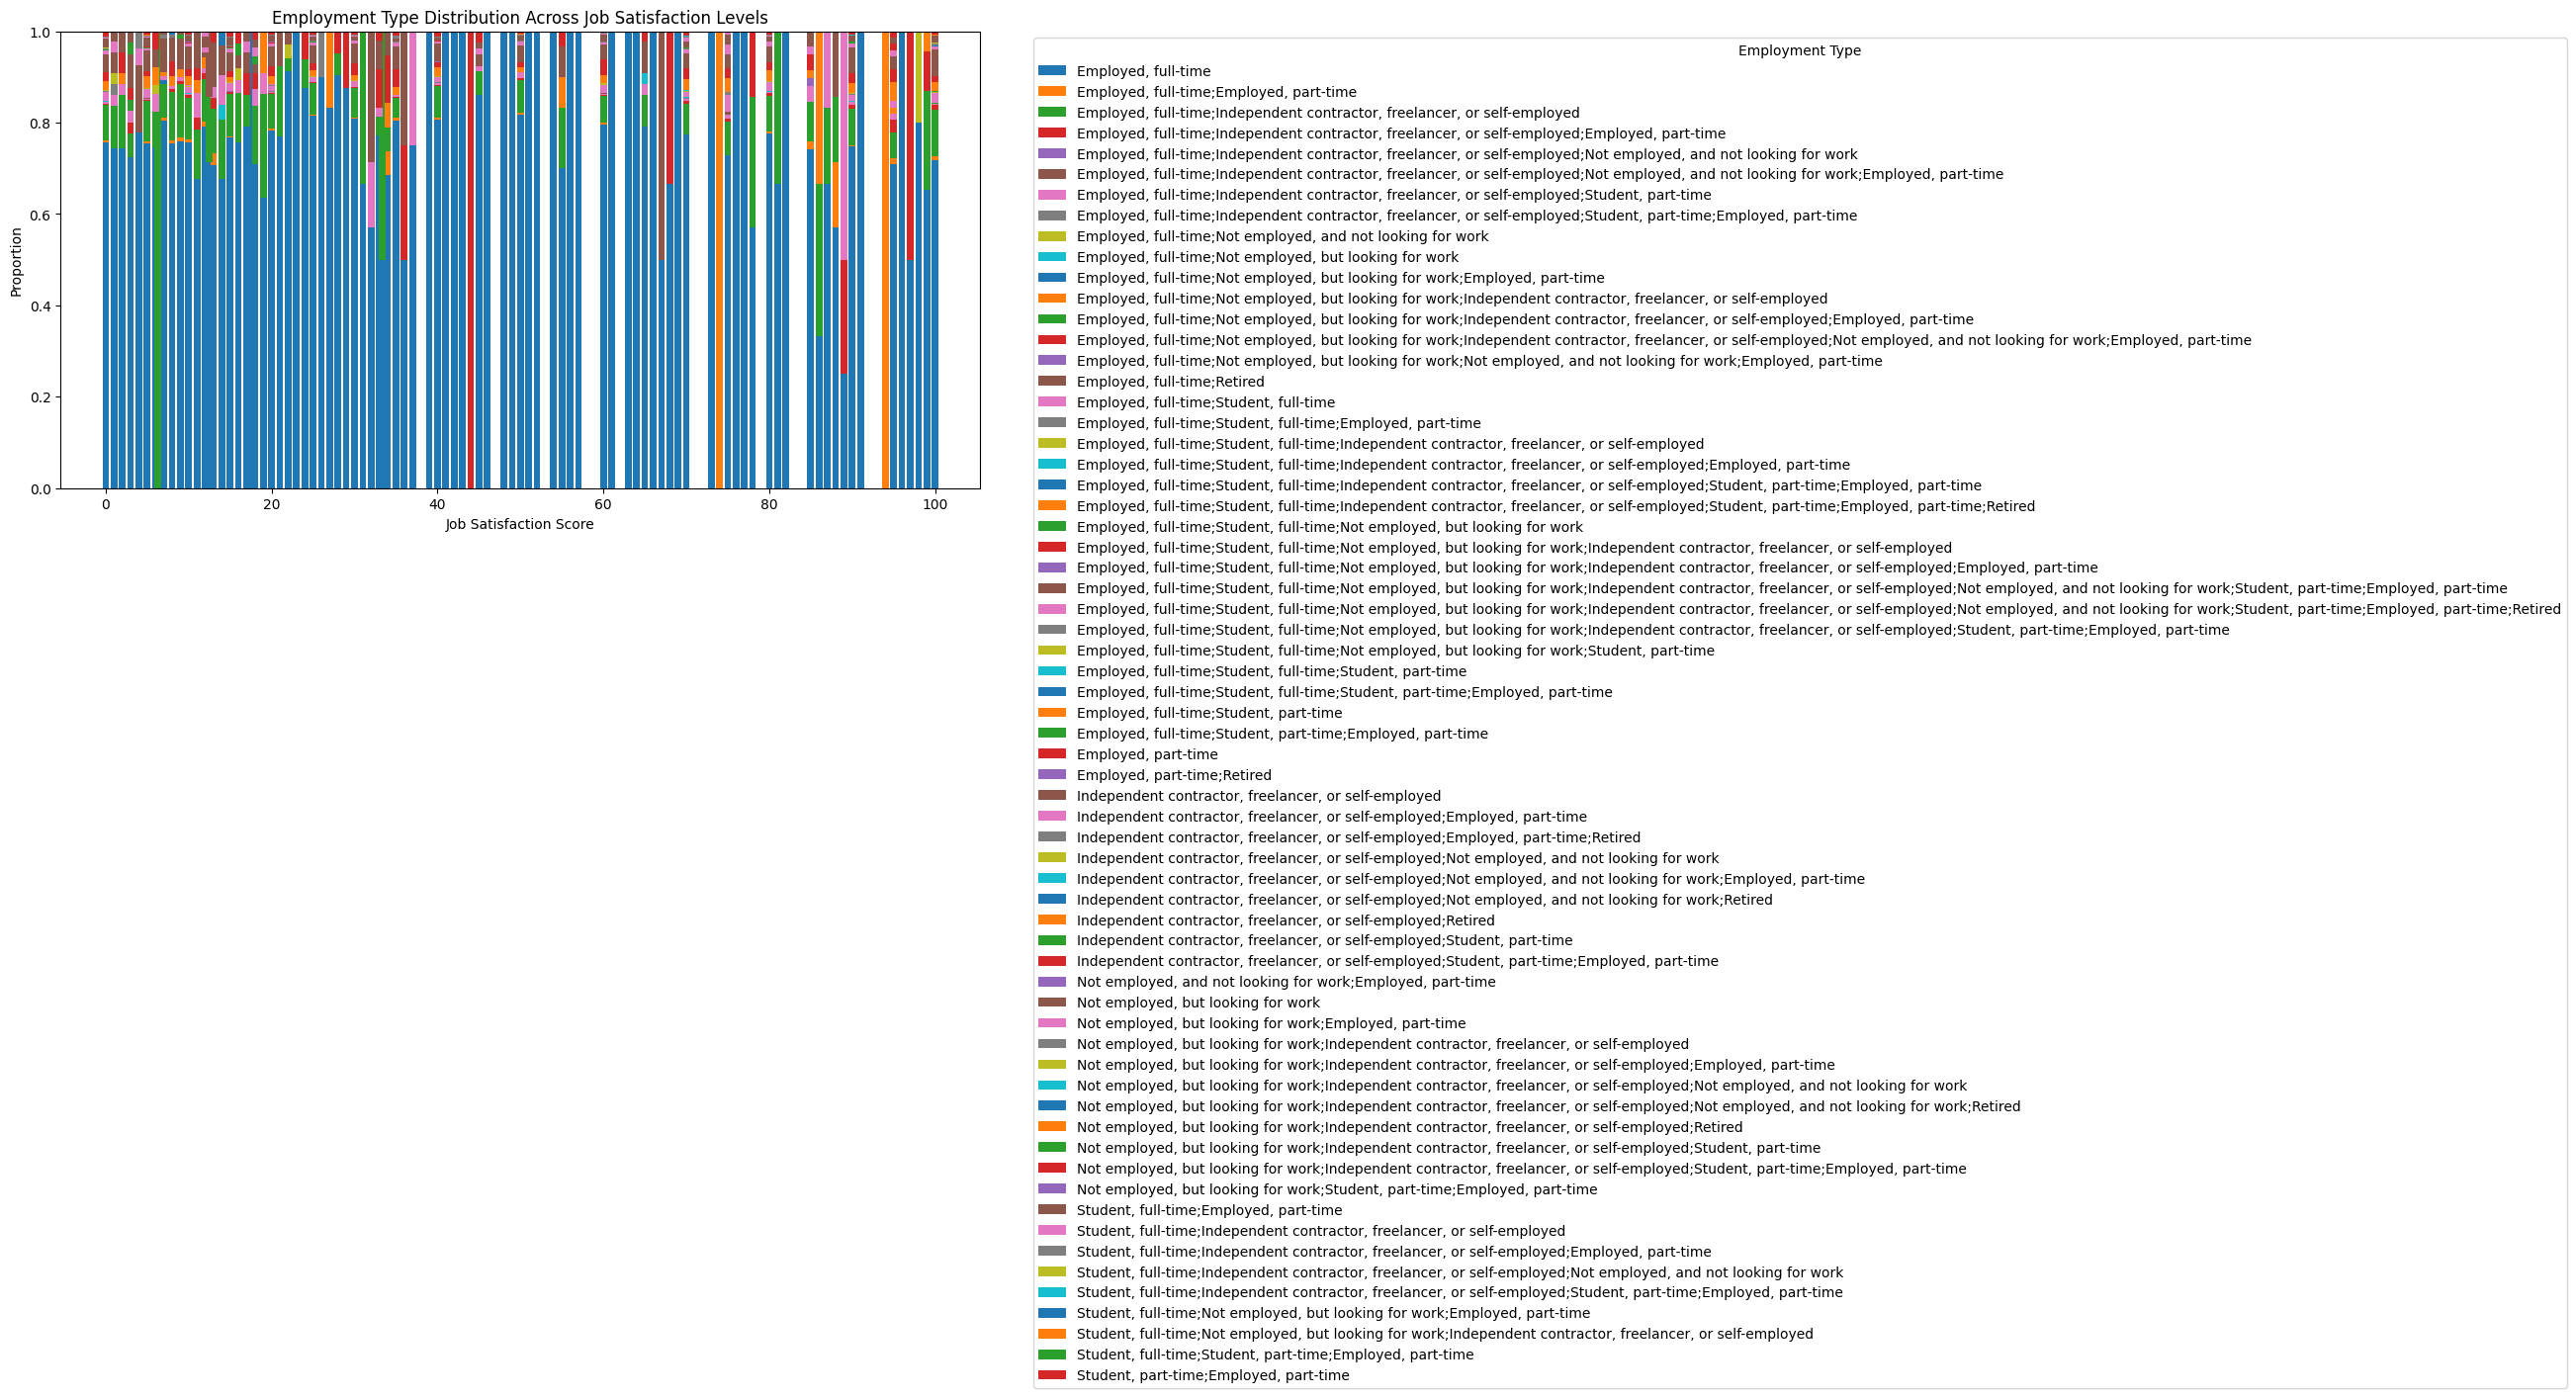

In [13]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CLEAN DATA
# -----------------------------
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

df_emp = df[['Employment', 'JobSatPoints_6']].dropna()

# -----------------------------
# GROUP DATA
# -----------------------------
emp_sat = df_emp.groupby(['JobSatPoints_6', 'Employment']).size().unstack(fill_value=0)

# Convert to proportions for better comparison
emp_sat_prop = emp_sat.div(emp_sat.sum(axis=1), axis=0)

# -----------------------------
# STACKED BAR CHART
# -----------------------------
plt.figure(figsize=(12,6))

bottom = None

for col in emp_sat_prop.columns:
    plt.bar(
        emp_sat_prop.index,
        emp_sat_prop[col],
        bottom=bottom,
        label=col
    )
    bottom = emp_sat_prop[col] if bottom is None else bottom + emp_sat_prop[col]

plt.title("Employment Type Distribution Across Job Satisfaction Levels")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Proportion")
plt.legend(title="Employment Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


In [ ]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CLEAN AGE GROUPS
# -----------------------------
age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df['AgeGroup'] = df['Age'].map(age_map)

# -----------------------------
# CLEAN DATA
# -----------------------------
df_lang = df[['AgeGroup', 'LanguageAdmired']].dropna()

# Split multiple languages into rows
df_lang = df_lang.assign(
    Language=df_lang['LanguageAdmired'].str.split(';')
).explode('Language')

df_lang['Language'] = df_lang['Language'].str.strip()

# -----------------------------
# GROUP AND COUNT
# -----------------------------
lang_counts = df_lang.groupby(['AgeGroup', 'Language']).size().unstack(fill_value=0)

# Convert to proportions
lang_props = lang_counts.div(lang_counts.sum(axis=1), axis=0)

# -----------------------------
# STACKED BAR CHART
# -----------------------------
plt.figure(figsize=(12,6))

bottom = None

for col in lang_props.columns:
    plt.bar(
        lang_props.index,
        lang_props[col],
        bottom=bottom,
        label=col
    )
    bottom = lang_props[col] if bottom is None else bottom + lang_props[col]

plt.title("Preferred Programming Languages by Age Group (Admired)")
plt.xlabel("Age Group")
plt.ylabel("Proportion")
plt.legend(title="Language", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


In [ ]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CLEAN DATA
# -----------------------------
df_plat = df[['Employment', 'PlatformAdmired']].dropna()

# Split multiple platforms into rows
df_plat = df_plat.assign(
    Platform=df_plat['PlatformAdmired'].str.split(';')
).explode('Platform')

df_plat['Platform'] = df_plat['Platform'].str.strip()

# -----------------------------
# GROUP AND COUNT
# -----------------------------
plat_counts = df_plat.groupby(['Employment', 'Platform']).size().unstack(fill_value=0)

# Convert to proportions for fair comparison
plat_props = plat_counts.div(plat_counts.sum(axis=1), axis=0)

# -----------------------------
# STACKED BAR CHART
# -----------------------------
plt.figure(figsize=(12,6))

bottom = None

for col in plat_props.columns:
    plt.bar(
        plat_props.index,
        plat_props[col],
        bottom=bottom,
        label=col
    )
    bottom = plat_props[col] if bottom is None else bottom + plat_props[col]

plt.title("Technology Adoption (Platform Admired) by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Proportion")
plt.xticks(rotation=90)

plt.legend(title="Platform", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
